In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torchvision.transforms as transforms
from torchsummary import summary
import os
import cv2
from torch import  randint
from pathlib import Path
from glob import glob
import numpy as np
from torch.utils.data import random_split, DataLoader
 
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(pretrained=True).to(device)
print(summary(model, (3, 224, 224)))

d:\Anaconda\envs\exercise\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Anaconda\envs\exercise\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [2]:
from random import shuffle, seed
seed(10)

train_dataset_dir = "Animals/training_set"
val_dataset_dir = "Animals/test_set"

class AnimalsDataset(Dataset):
    def __init__(self, folder):
        cats = glob(folder + "/cats/*.jpg")
        dogs = glob(folder + "/dogs/*.jpg")
        self.files = cats[:500] + dogs[:500]
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        shuffle(self.files)
        self.targets = [file.split('/')[-1].startswith('dog') for file in self.files]
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        file = self.files[idx]
        target = self.targets[idx]
        image = cv2.imread(file)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        image= torch.tensor(image/255, dtype=torch.float32)
        image = image.permute(2, 0, 1)
        image = self.normalize(image)
        return image.to(device), torch.tensor([target]).float().to(device)
    


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].


tensor([0.], device='cuda:0')


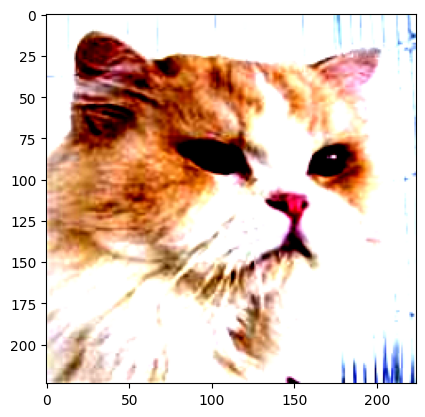

In [3]:
from matplotlib import pyplot as plt


train_dataset = AnimalsDataset(train_dataset_dir)
test_dataset = AnimalsDataset(val_dataset_dir)
# print(len(dataset))
im, label = train_dataset[100]
print(label)

plt.imshow(im.permute(1, 2, 0).cpu())
plt.show()


In [9]:
def acc(x, y, model):
    with torch.no_grad():
        model.eval()
        y_hat = model(x)
        y_hat = (y_hat > 0.5).float()
        return (y_hat == y).float().mean().item()
    
def train(model, trn_dl, val_dl,criterion, optimizer, epochs=10):
    train_losses = []
    train_acc = []
    test_acc = []
    
    for epoch in range(epochs):
        model.train()
        losses = []
        accuracy = []
        print(f"Epoch {epoch+1}:", end="")
        for ix, (ims, labels) in enumerate(iter(trn_dl)):
            y_hat = model(ims)
            batch_loss = criterion(y_hat, labels)
            correct = acc(ims, labels, model)
            optimizer.zero_grad()
            batch_loss.backward()
            optimizer.step()
            losses.append(batch_loss.item())
            accuracy.append(correct)
        train_loss = np.mean(losses)
        train_losses.append(train_loss)
        train_accuracy_epoch = np.mean(accuracy)
        train_acc.append(train_accuracy_epoch)
        print(f"Train loss: {train_loss}, Train accuracy: {train_accuracy_epoch}")
        
        val_loss, val_accuracy_epoch = test(model, val_dl, criterion)
        test_acc.append(val_accuracy_epoch)
    epo = np.arange(1, epoch+2)
    plt.plot(epo, train_acc)
    plt.plot(epo, test_acc)
    plt.legend(['train_acc', 'test_acc'])
    plt.show()

    # model.save(model.state_dict(),"vgg16_animals_classifier.pth")
    

def test(model, val_dl, criterion):
    model.eval()
    losses = []
    accuracy = []
    with torch.no_grad():
        for ix, (ims, labels) in enumerate(iter(val_dl)):
            y_hat = model(ims)
            batch_loss = criterion(y_hat, labels)
            correct = acc(ims, labels, model)
            losses.append(batch_loss.item())
            accuracy.append(correct)
    test_loss = np.mean(losses)
    test_accuracy_epoch = np.mean(accuracy)
    print(f"Test loss: {test_loss}, Test accuracy: {test_accuracy_epoch}")
    return test_loss, test_accuracy_epoch

trn_dl = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_dl = DataLoader(test_dataset, batch_size=32, shuffle=True, drop_last=True)
from torchvision.models import VGG16_Weights
model = models.vgg16(weights=VGG16_Weights.DEFAULT).to(device)
for param in model.parameters():
    param.requires_grad = False
model.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=512, out_features=128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(in_features=128, out_features=1),
    nn.Sigmoid()
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 10
loss_function = nn.BCELoss()

    




Epoch 1:Train loss: 0.23031144529100386, Train accuracy: 0.9274193548387096
Test loss: 0.07377442549313268, Test accuracy: 0.9818548387096774
Epoch 2:Train loss: 0.05178363969729793, Train accuracy: 0.9798387096774194
Test loss: 0.05662094071627625, Test accuracy: 0.9828629032258065
Epoch 3:Train loss: 0.0340435991153842, Train accuracy: 0.9858870967741935
Test loss: 0.05464705306616041, Test accuracy: 0.9808467741935484
Epoch 4:Train loss: 0.02614857007809464, Train accuracy: 0.9899193548387096
Test loss: 0.0552945125081967, Test accuracy: 0.9798387096774194
Epoch 5:Train loss: 0.02132044148991906, Train accuracy: 0.9949596774193549
Test loss: 0.05425029158246734, Test accuracy: 0.9848790322580645
Epoch 6:Train loss: 0.017416830961367175, Train accuracy: 0.9949596774193549
Test loss: 0.05469793608156784, Test accuracy: 0.9848790322580645
Epoch 7:Train loss: 0.013024223048330074, Train accuracy: 0.9959677419354839
Test loss: 0.05506391610739933, Test accuracy: 0.9858870967741935
Epoch 

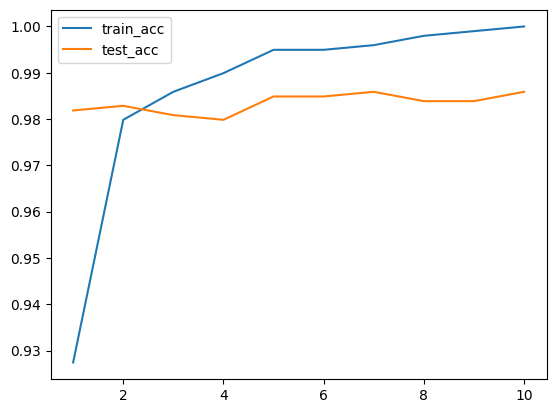

In [8]:
train(model, trn_dl, val_dl, loss_function, optimizer, epochs)
